# Análise exploratória de demanda, preço e margem

Este notebook reproduz as principais leituras da aplicação Streamlit. A base é sintética, tem semente fixa e representa combinações semanais de produto e canal em 2025.

Pergunta central: **quais fatores estão mais associados ao volume vendido e onde o crescimento deixa de gerar contribuição?**

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.analysis import associacoes_volume, calcular_kpis, curva_abc, resumo_canal, resumo_desconto, resumo_mensal
from src.data import carregar_dados
from src.metrics import adicionar_metricas

dados = adicionar_metricas(carregar_dados(RAIZ / "data" / "ecommerce_2025.csv"))
print(f"Linhas: {len(dados):,}")
print(f"Produtos: {dados['sku'].nunique()}")
print(f"Período: {dados['semana'].min().date()} a {dados['semana'].max().date()}")

Linhas: 7,488
Produtos: 48
Período: 2025-01-06 a 2025-12-29


## 1. Indicadores gerais

As métricas financeiras separam custo do produto, custo do canal e investimento em mídia.

In [2]:
kpis = calcular_kpis(dados)
pd.DataFrame(...)  # resumo formatado

Indicador,Resultado
Receita líquida,"R$ 15,699,970"
Lucro bruto,"R$ 5,392,012"
Contribuição,"R$ 2,964,997"
Unidades líquidas,"88,488"
Conversão,4.3%
Margem de contribuição,18.9%


## 2. Sazonalidade do resultado

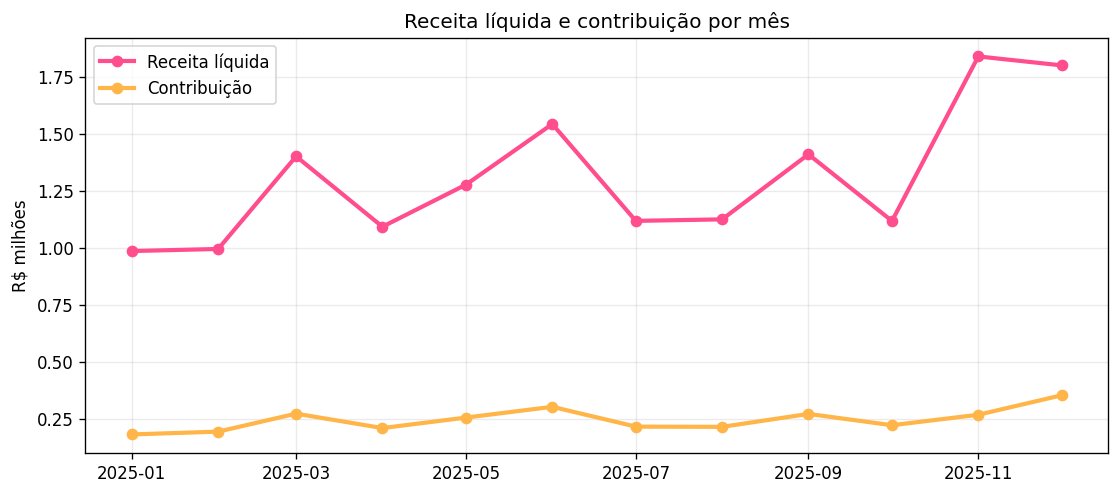

In [3]:
mensal = resumo_mensal(dados)
# gráfico de receita líquida e contribuição por mês

Novembro apresenta o maior faturamento por causa da sazonalidade e dos descontos programados. A contribuição não cresce na mesma proporção.

## 3. Fatores associados ao volume

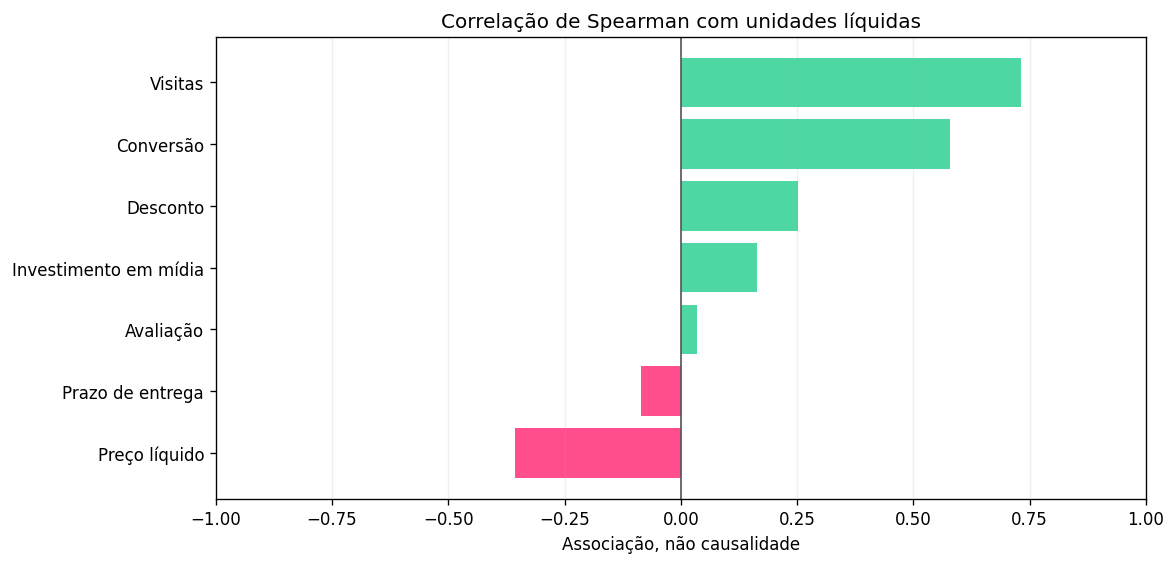

fator,correlacao_spearman
Visitas,0.732142
Conversão,0.578580
Desconto,0.251701
Investimento em mídia,0.162977
Avaliação,0.034698
Prazo de entrega,-0.084634
Preço líquido,-0.356659


In [4]:
associacoes = associacoes_volume(dados)
# gráfico da correlação de Spearman

Visitas e conversão apresentam as associações positivas mais fortes. Preço líquido tem associação negativa. Os coeficientes descrevem a base e não estimam efeito causal.

## 4. Desconto, volume e contribuição

In [5]:
descontos = resumo_desconto(dados)
descontos

Faixa,Unidades,Receita,Contribuição,Margem,Conversão
Sem desconto,13065,"R$ 2,647,888","R$ 657,262",24.8%,3.4%
5%,13047,"R$ 2,536,175","R$ 584,759",23.1%,3.8%
10%,19845,"R$ 3,547,212","R$ 739,842",20.9%,4.1%
15%,17682,"R$ 3,046,796","R$ 523,433",17.2%,4.5%
20% ou mais,24849,"R$ 3,921,898","R$ 459,702",11.7%,5.2%


Faixas de desconto maiores concentram mais unidades e conversão, porém perdem margem. Isso não é uma recomendação de preço.

## 5. Eficiência por canal

In [6]:
canais = resumo_canal(dados)
canais

Canal,Receita,Contribuição,Margem,Conversão,ROAS
Site,"R$ 5,254,106","R$ 1,195,329",22.8%,4.3%,6.53
Aplicativo,"R$ 5,228,020","R$ 1,350,172",25.8%,5.2%,7.84
Marketplace,"R$ 5,217,843","R$ 419,496",8.0%,3.6%,5.46


## 6. Concentração do portfólio

In [7]:
produtos = curva_abc(dados)
# resumo por classe ABC

Classe,Produtos,Receita,Participação
A,28,"R$ 12,351,159",78.7%
B,13,"R$ 2,531,929",16.1%
C,7,"R$ 816,882",5.2%


## Conclusão

A base mostra que escala e eficiência precisam ser avaliadas juntas. Visitas e conversão acompanham o volume, mas desconto e taxas de canal alteram a transformação da receita em contribuição. A curva ABC adiciona uma visão de concentração e risco operacional.

Próximo passo com dados reais: validar regras contábeis, controlar diferenças entre categorias e estimar elasticidade com desenho experimental ou método causal adequado.